In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
d=50
beta=0.3
target_sum = int(d**(1 -beta ))
psi_vec = np.random.normal(0,1,d)
a_values=np.arange(1,11)

eta_j = np.zeros(d, dtype=int)
eta_j[:target_sum] = 1  
np.random.shuffle(eta_j)  


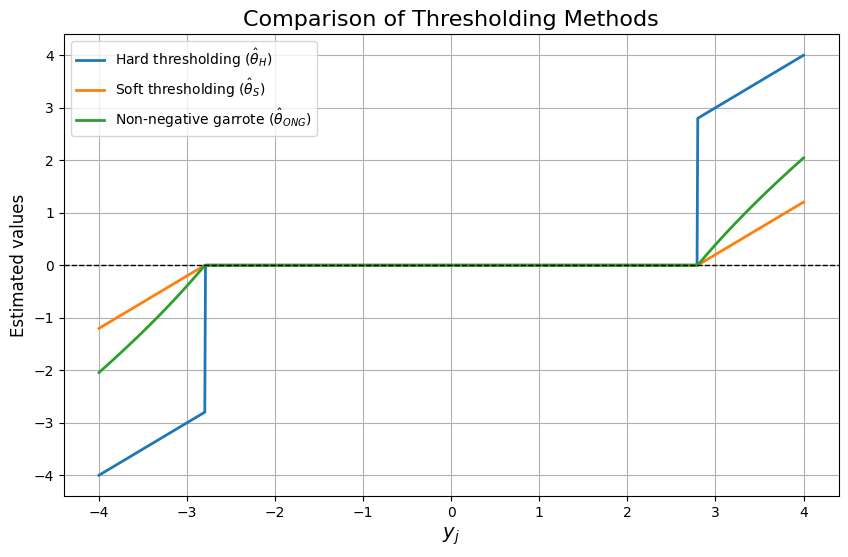

In [3]:
tau=np.sqrt(2*np.log(d))
y_j = np.linspace(-4, 4, 1000)

# we are defining the estimators with threshold
theta_H = y_j * (np.abs(y_j) > tau)
theta_S = np.sign(y_j) * np.maximum(np.abs(y_j) - tau, 0)
theta_ONG = y_j * np.maximum(1 - (tau**2) / (y_j**2), 0)


plt.figure(figsize=(10, 6))
plt.plot(y_j, theta_H, label='Hard thresholding ($\\hat{\\theta}_H$)', linewidth=2)
plt.plot(y_j, theta_S, label='Soft thresholding ($\\hat{\\theta}_S$)', linewidth=2)
plt.plot(y_j, theta_ONG, label='Non-negative garrote ($\\hat{\\theta}_{ONG}$)', linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('$y_j$', fontsize=14)
plt.ylabel('Estimated values', fontsize=12)
plt.title('Comparison of Thresholding Methods', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

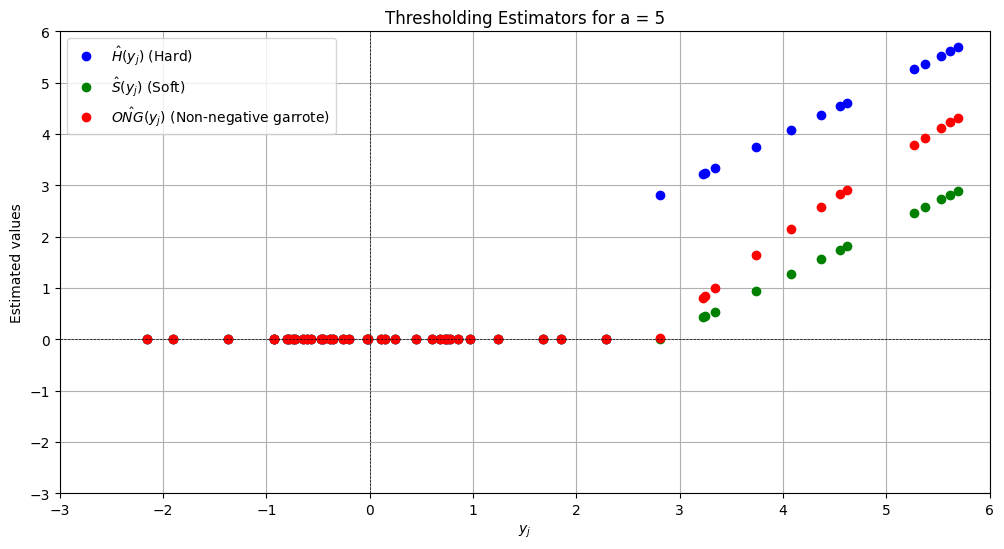

In [4]:

a_values = np.arange(1, 11)  


def positive_part(x):
    return np.maximum(0, x)

# here we are using dict method to call for every value of a 
theta_star_dict = {a: a * eta_j.T for a in a_values} 

y_j_dict = {a: a * eta_j + psi_vec for a in a_values}
#print(y_j_dict)



H_dict = {a: y * (np.abs(y) > tau) for a, y in y_j_dict.items()}  # Hard thresholding
S_dict = {a: y * positive_part(1 - tau / np.abs(y)) for a, y in y_j_dict.items()}  # Soft thresholding
ONG_dict = {a: y * positive_part(1 - (tau**2) / (y**2)) for a, y in y_j_dict.items()}  # Non-negative garrote

# Plot for a selected value of a (e.g., a = 5)
selected_a = 5
y_j = y_j_dict[selected_a]
H = H_dict[selected_a]
S = S_dict[selected_a]
ONG = ONG_dict[selected_a]

plt.figure(figsize=(12, 6))
plt.plot(y_j, H, 'o', label=r'$\hat{H}(y_j)$ (Hard)', color='blue')
plt.plot(y_j, S, 'o', label=r'$\hat{S}(y_j)$ (Soft)', color='green')
plt.plot(y_j, ONG, 'o', label=r'$\hat{ONG}(y_j)$ (Non-negative garrote)', color='red')

# Customizing the plot
plt.title(f'Thresholding Estimators for a = {selected_a}')
plt.xlabel('$y_j$')
plt.xlim(-3,6)
plt.ylim(-3,6)
plt.ylabel('Estimated values')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.grid(True)

plt.show()


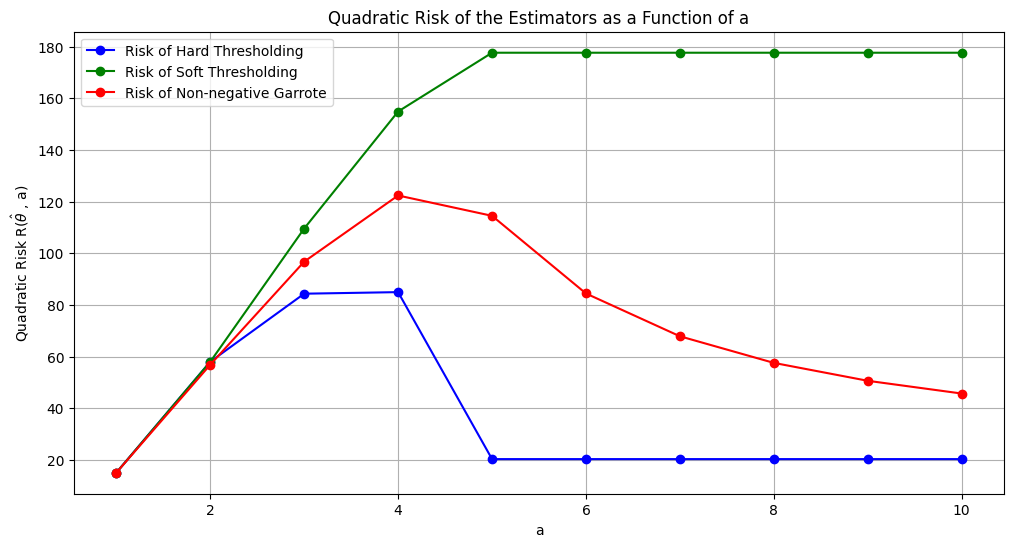

In [5]:
# calculating the quadratic risk 
risk_H = []
risk_S = []
risk_ONG = []

for a in a_values:
    theta_star = a * eta_j.T  
    H = H_dict[a]             
    S = S_dict[a]             
    ONG = ONG_dict[a]         
    
    # compute quadratic risks 
    risk_H.append(np.linalg.norm(theta_star - H)**2)
    risk_S.append(np.linalg.norm(theta_star - S)**2)
    risk_ONG.append(np.linalg.norm(theta_star - ONG)**2)


plt.figure(figsize=(12, 6))
plt.plot(a_values, risk_H, '-o', label='Risk of Hard Thresholding', color='blue')
plt.plot(a_values, risk_S, '-o', label='Risk of Soft Thresholding', color='green')
plt.plot(a_values, risk_ONG, '-o', label='Risk of Non-negative Garrote', color='red')


plt.title('Quadratic Risk of the Estimators as a Function of a')
plt.xlabel('a')
plt.ylabel('Quadratic Risk R($\\hat{\\theta}$ , a)')
plt.grid(True)
plt.legend()

plt.show()



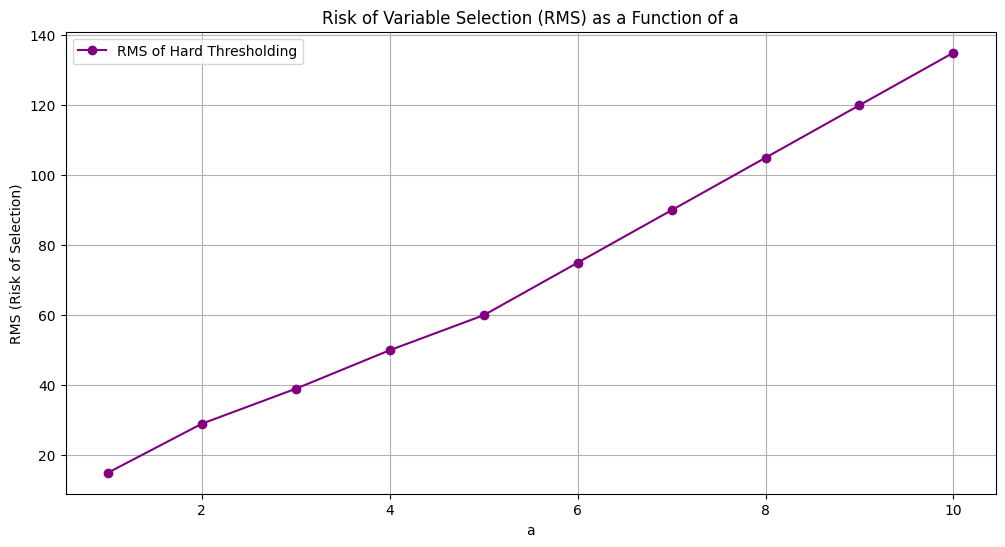

In [6]:
def hard_threshold_selection(y, tau):
    return (np.abs(y) >= tau).astype(int)

# calculating RMS for hard thresholding
rms_H = []

for a in a_values:
    theta_star = a * eta_j.T  
    y_j = y_j_dict[a]         
    theta_hat = hard_threshold_selection(y_j, tau)  
    
    
    rms_H.append(np.sum(np.abs(theta_hat - theta_star)))


plt.figure(figsize=(12, 6))
plt.plot(a_values, rms_H, '-o', label='RMS of Hard Thresholding', color='purple')

plt.title('Risk of Variable Selection (RMS) as a Function of a')
plt.xlabel('a')
plt.ylabel('RMS (Risk of Selection)')
plt.grid(True)
plt.legend()

plt.show()

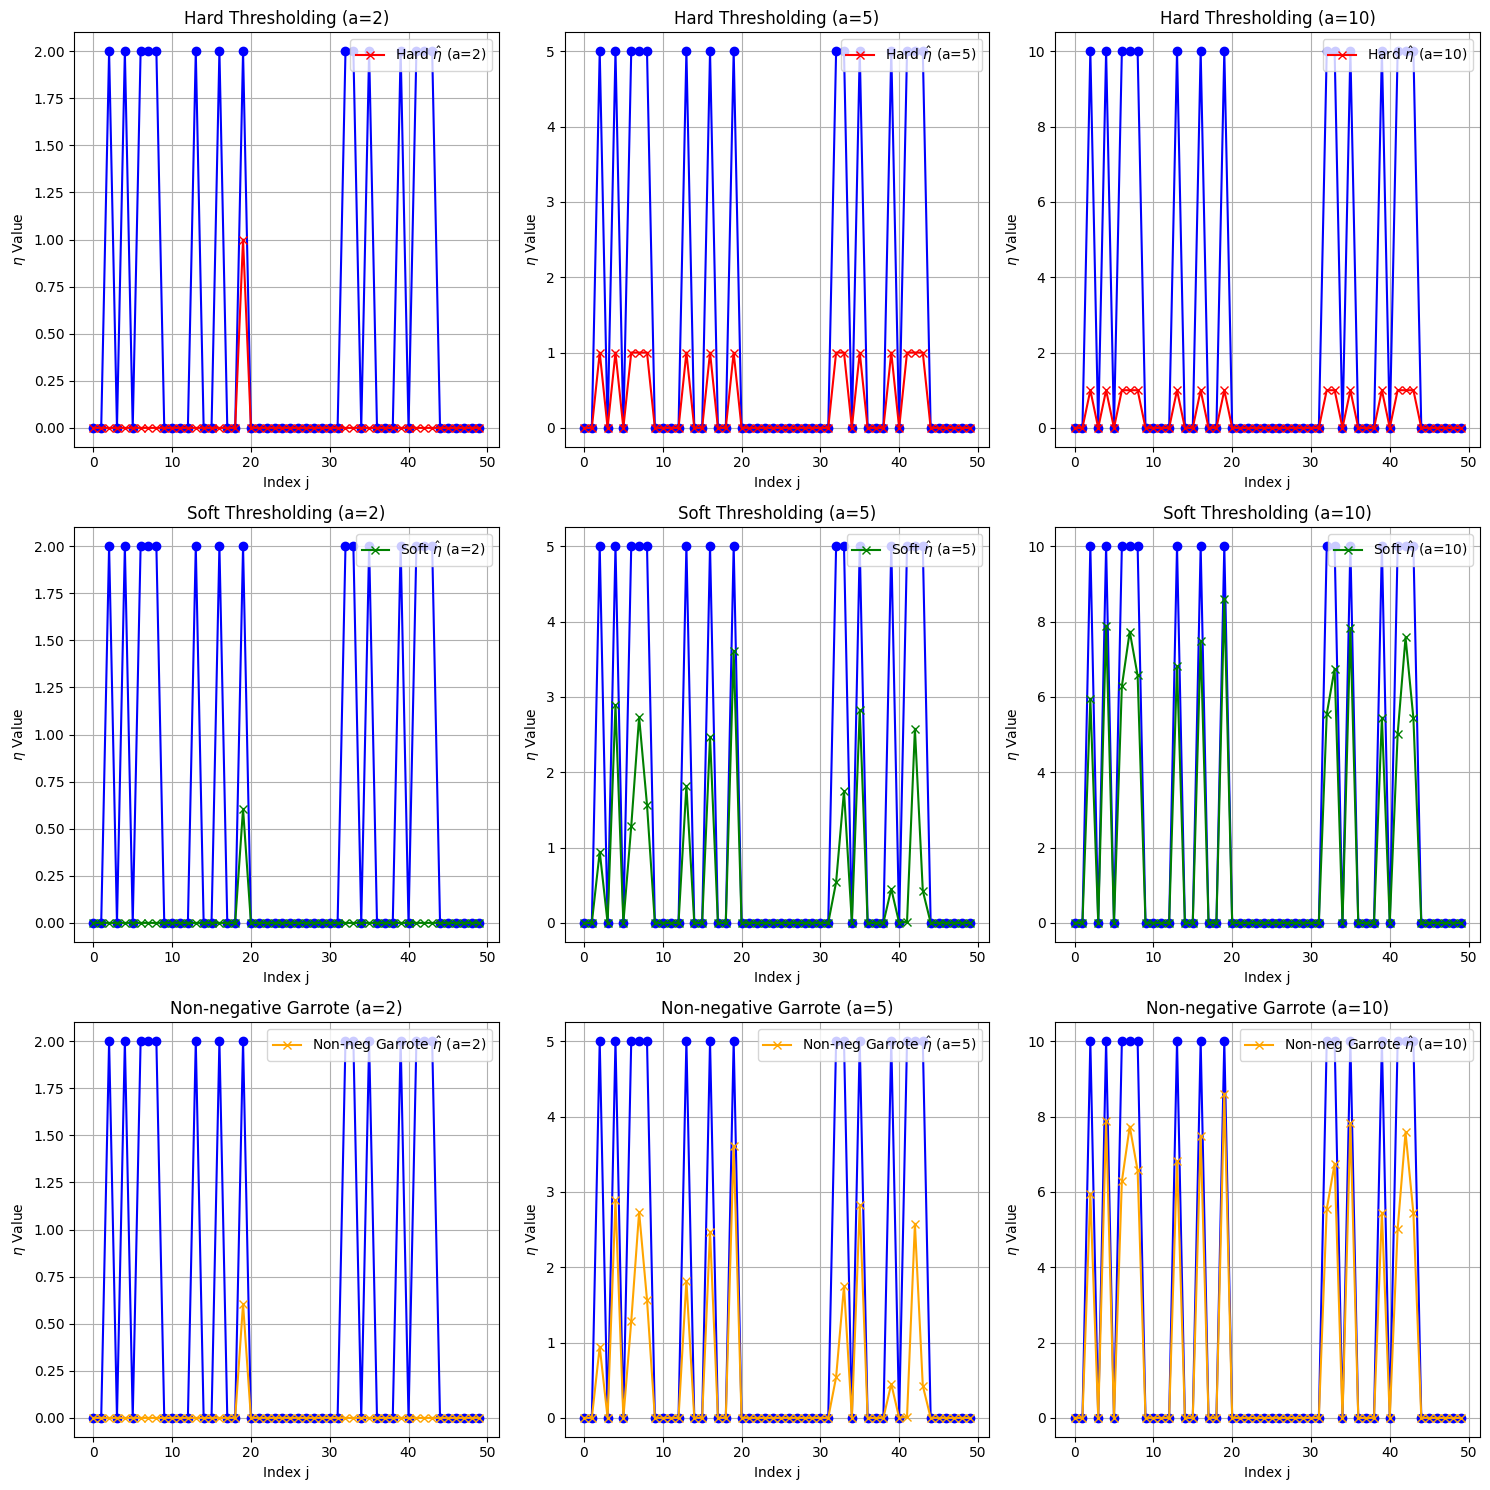

In [7]:



def hard_threshold_selection(y, tau):
    return (np.abs(y) >= tau).astype(int)

def soft_threshold_selection(y, tau):
    return np.sign(y) * np.maximum(np.abs(y) - tau, 0)


def non_negative_garrote_selection(y, tau):
    return np.maximum(y - tau, 0)


rms_H = []
rms_S = []
rms_NG = []
plt.figure(figsize=(15, 15))
for i, a in enumerate([2, 5, 10], start=1):
    theta_star = a * eta_j.T  
    y_j = y_j_dict[a]
    
    
    theta_hat_H = hard_threshold_selection(y_j, tau)  
    theta_hat_S = soft_threshold_selection(y_j, tau)  
    theta_hat_NG = non_negative_garrote_selection(y_j, tau)  
  
    rms_H.append(np.sum(np.abs(theta_hat_H - theta_star)))
    rms_S.append(np.sum(np.abs(theta_hat_S - theta_star)))
    rms_NG.append(np.sum(np.abs(theta_hat_NG - theta_star)))


    plt.subplot(3, 3, i)
    plt.plot(theta_star, 'o-',  color='blue')
    plt.plot(theta_hat_H, 'x-', label=f'Hard $\\hat{{\\eta}}$ (a={a})', color='red')
    plt.title(f'Hard Thresholding (a={a})')
    plt.xlabel('Index j')
    plt.ylabel('$\\eta$ Value')
    plt.legend(loc='upper right')
    plt.grid(True)
    
   
    plt.subplot(3, 3, i + 3)
    plt.plot(theta_star, 'o-',  color='blue')
    plt.plot(theta_hat_S, 'x-', label=f'Soft $\\hat{{\\eta}}$ (a={a})', color='green')
    plt.title(f'Soft Thresholding (a={a})')
    plt.xlabel('Index j')
    plt.ylabel('$\\eta$ Value')
    plt.legend(loc='upper right')
    plt.grid(True)
    
   
    plt.subplot(3, 3, i + 6)
    plt.plot(theta_star, 'o-', color='blue')
    plt.plot(theta_hat_NG, 'x-', label=f'Non-neg Garrote $\\hat{{\\eta}}$ (a={a})', color='orange')
    plt.title(f'Non-negative Garrote (a={a})')
    plt.xlabel('Index j')
    plt.ylabel('$\\eta$ Value')
    plt.legend(loc='upper right')
    plt.grid(True)

plt.tight_layout()

plt.show()

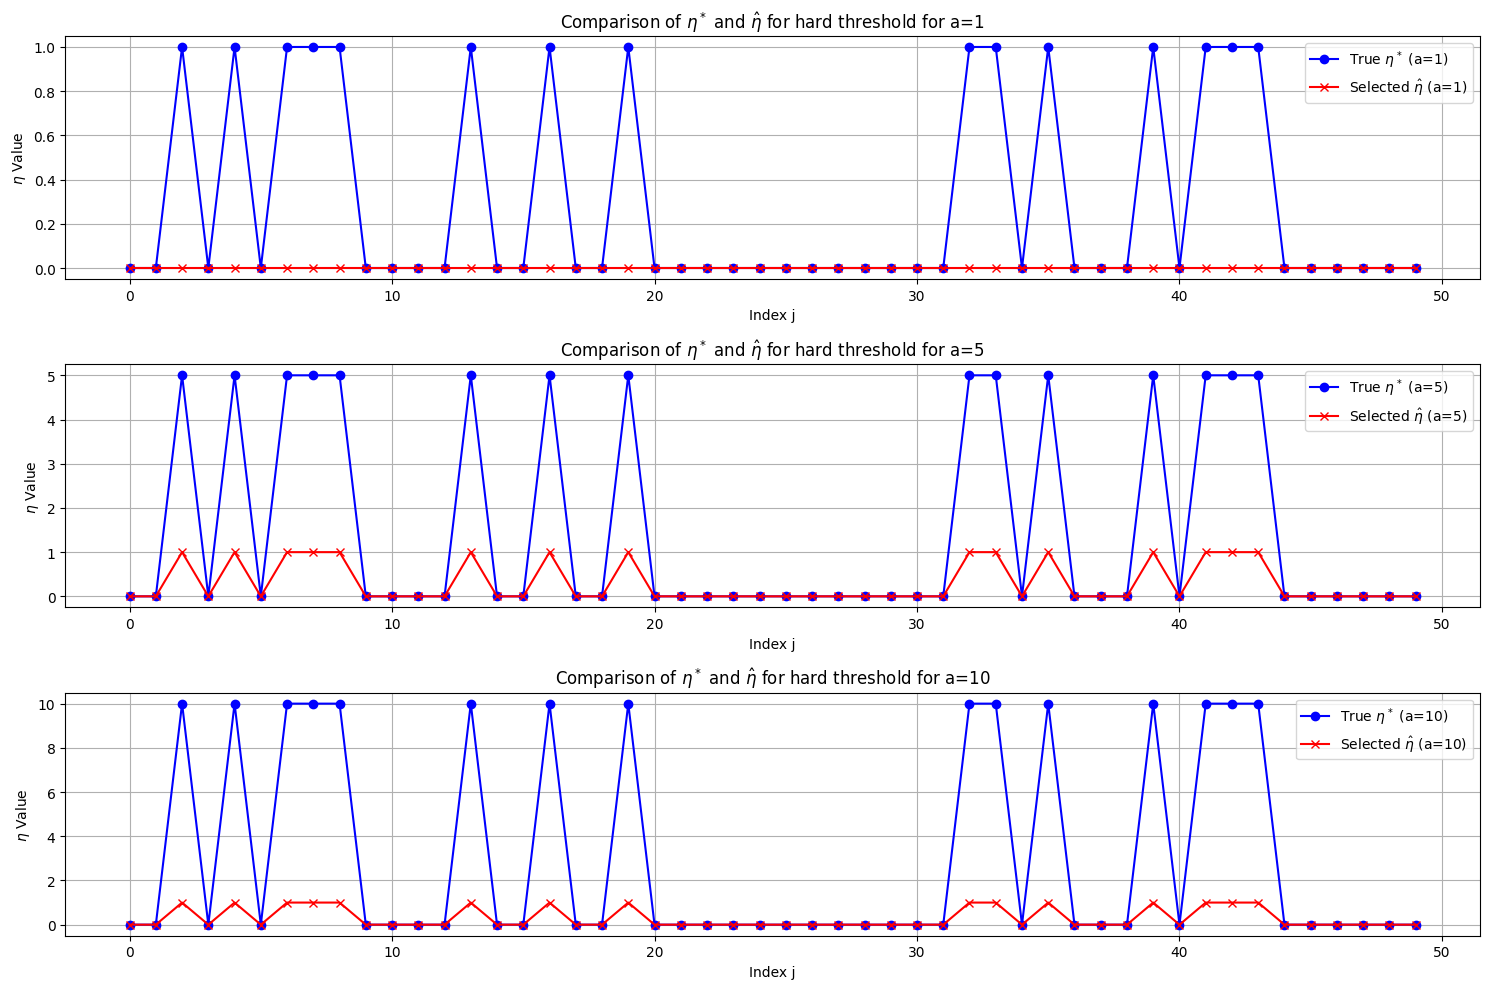

In [8]:

plt.figure(figsize=(15, 10))

for i, a in enumerate([1, 5, 10], start=1):
    theta_star = a * eta_j.T  
    y_j = y_j_dict[a]         #
    theta_hat = hard_threshold_selection(y_j, tau)  
    
    
    plt.subplot(3, 1, i)
    plt.plot(theta_star, 'o-', label=f'True $\\eta^*$ (a={a})', color='blue')
    plt.plot(theta_hat, 'x-', label=f'Selected $\\hat{{\\eta}}$ (a={a})', color='red')
    plt.title(f'Comparison of $\\eta^*$ and $\\hat{{\\eta}}$ for hard threshold for a={a}')
    plt.xlabel('Index j')
    plt.ylabel('$\\eta$ Value')
    plt.legend(loc= 'upper right')
    plt.grid(True)

plt.tight_layout()
plt.show()

Indices où est différent de 0: [ 9 29]
Indices où est différent de 0: 2


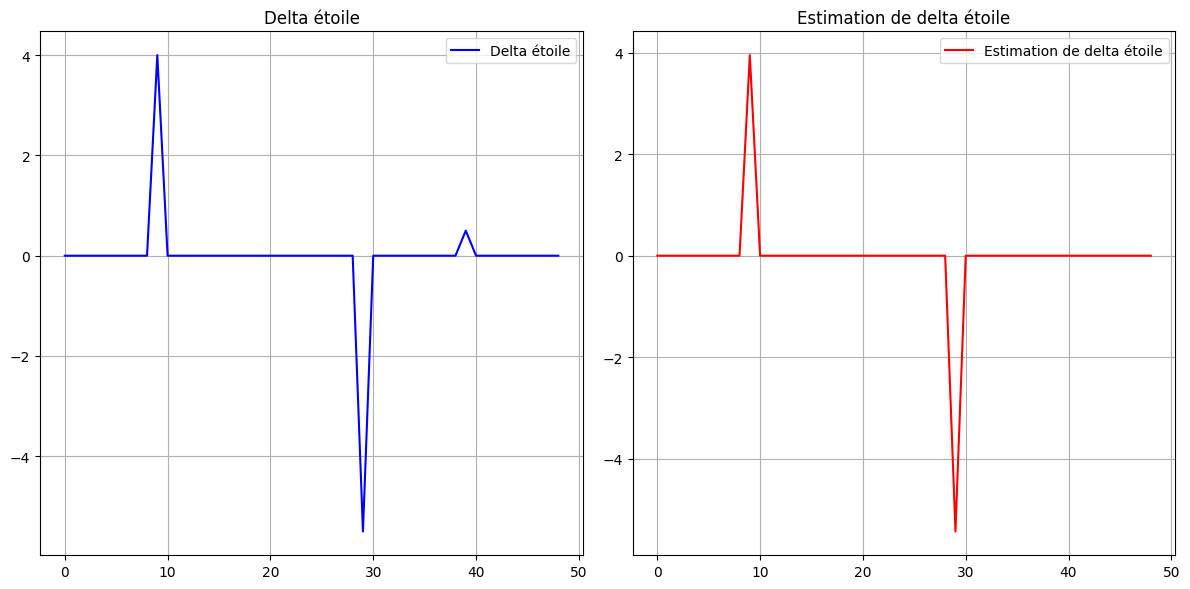

In [9]:

eps = 1/np.sqrt(d)
theta_etoile = np.concatenate([np.full(10, 3), np.full(20, 7), np.full(10, 1.5), np.full(10, 2)])
psi_vec_org=np.random.normal(0,1,50)



delta_etoile = np.diff(theta_etoile)
def hard_thresholding_for_data(Y, threshold=tau):
    return np.where(np.abs(Y) > threshold, Y, 0)


Z = np.diff(psi_vec_org)
Y = delta_etoile + eps * Z

est = hard_thresholding_for_data(Y)
print("Indices où est différent de 0:", np.where(est != 0)[0])
print("Indices où est différent de 0:", len(np.where(est != 0)[0]))



plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(delta_etoile, color='blue' ,label='Delta étoile')
plt.title('Delta étoile')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(est, color='red', label='Estimation de delta étoile')
plt.title('Estimation de delta étoile')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
df_data= pd.read_csv('data.csv')

In [11]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   process.b1.capacity  2043 non-null   int64  
 1   process.b2.capacity  2043 non-null   int64  
 2   process.b3.capacity  2043 non-null   int64  
 3   process.b4.capacity  2043 non-null   int64  
 4   property.price       2043 non-null   int64  
 5   property.product     2043 non-null   int64  
 6   property.winner      2043 non-null   int64  
 7   verification.result  2043 non-null   bool   
 8   verification.time    2043 non-null   float64
dtypes: bool(1), float64(1), int64(7)
memory usage: 129.8 KB


In [12]:
df_data['property.price'].unique()


array([59, 60, 69, 70, 61, 62, 63, 64, 65, 66, 67, 68, 71, 72, 73, 74, 75,
       76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90])

Indices où est différent de 0: 24


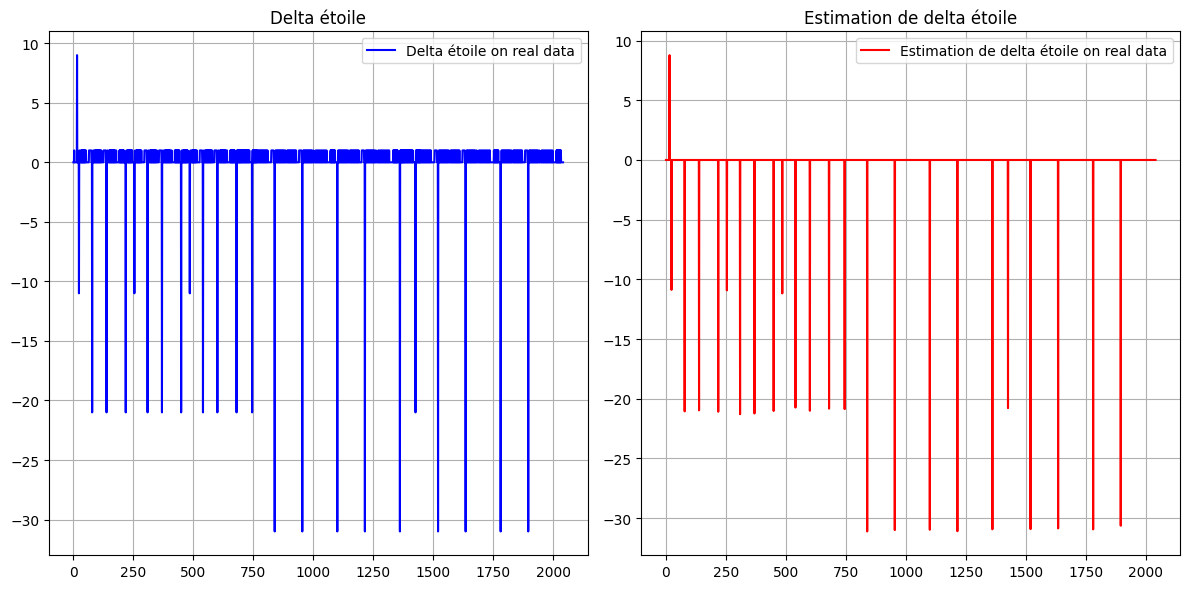

In [13]:
eps = 1/np.sqrt(d)
theta_etoile = df_data['property.price']
psi_vec= np.random.normal(0,1, 2043)



delta_etoile = np.diff(theta_etoile)



Z = np.diff(psi_vec)
Y = delta_etoile + eps * Z

est = hard_thresholding_for_data(Y)
#print("Indices où est différent de 0:", np.where(est != 0)[0])
print("Indices où est différent de 0:", len(np.where(est != 0)[0]))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(delta_etoile, color='blue' ,label='Delta étoile on real data')
plt.title('Delta étoile')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.plot(est, color='red', label='Estimation de delta étoile on real data')
plt.title('Estimation de delta étoile')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()